# Jupyter notebook

In [1]:
%load_ext autotime
%matplotlib inline

time: 490 ms (started: 2026-05-30 18:22:21 +03:00)


## Замер времени выполнения

In [2]:
import time

start_time = time.perf_counter()

time: 305 μs (started: 2026-05-30 18:22:22 +03:00)


## Подключаем основные модули

In [3]:
import socket

import clickhouse_connect
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from my_module.my_func import (
    get_null_exists_estimation,
    get_uniq_estimation,
    highlight_values,
)


time: 445 ms (started: 2026-05-30 18:22:22 +03:00)


## Объявляем основные переменные
`local_host_name` - локальное имя хоста<br>
`docker_host_name` - docker имя хоста<br>
`sample_percent` - размер выборки в процентах<br>
`sample_count` - кол-во выборок<br>
`db` - база данных<br>
`table` - название таблицы<br>


In [4]:
local_host_name = "home-NMH-WDX9"
docker_host_name = "service.db_clickhouse"

db = "cars"
table = "cars_sales"

sample_percent = 0.01
sample_count = 3

time: 356 μs (started: 2026-05-30 18:22:22 +03:00)


## Подключаемся к база данных `clickhouse`

Подключение к `ClickHouse` через официальный драйвер `clickhouse-connect`.<br>
Если запуск `.ipynb` происходит на локальной машине а не в `docker` то `host = "localhost"`.<br>
Иначе указывается адрес сурвиса в рамках docker - `"service.db_clickhouse"`.

Для корректной работы `home-NMH-WDX9` нужно заменить на имя вашей локальной машины.

In [5]:
hostname = socket.gethostname()
host = docker_host_name
if hostname == local_host_name:
    host = "localhost"

client = clickhouse_connect.get_client(
    host=host, port=8123, username="default", password=""
)

time: 24.1 ms (started: 2026-05-30 18:22:22 +03:00)


## Получаем общее кол-во записей в таблице `car_sales`

Получаем общее кол-во записей в таблице `car_sales`. 

На основании полученной информаци формируем размер выборки `sample_size`. <br>
Размер выборки формируется в зависимости от значения `sample_percent`, которое задается в процентах от общего кол-ва записей в таблице.

In [6]:
sql = f"SELECT COUNT(*) FROM {db}.{table};"  # noqa: S608
result = client.query(sql)
rows_count = result.result_rows[0][0]
sample_size = round(rows_count * sample_percent)
info_dict = {
    "Metric": [
        f"Кол-во записей в таблице {db}.{table}",
        f"Размер выборки ({sample_percent * 100}%)",
    ],
    "Value": [f"{rows_count:_d}", f"{sample_size:_d}"],
}
info_df = pd.DataFrame(info_dict)
info_df

,Metric,Value
0,Кол-во записей в таблице cars.cars_sales,1_294_757
1,Размер выборки (1.0%),12_948


time: 16.3 ms (started: 2026-05-30 18:22:22 +03:00)


## Формирование отчета аналогичного `pandas .info()`

In [ ]:
sql = f"DESCRIBE TABLE {db}.{table}"
df_table_columns = client.query_df(sql)

table_columns = df_table_columns["name"].to_list()
df_table_columns.set_index("name", inplace=True)

field_not_null_counts = {}
field_uniq = {}
for column in table_columns:
    sql = f"""SELECT
    uniq(`{column}`) as uniq_count,
    count(*) as non_null_count
    FROM {db}.{table}
    WHERE `{column}` IS NOT NULL;"""  # noqa: S608

    q = client.query(sql)
    field_not_null_counts[column] = q.result_rows[0][1]
    field_uniq[column] = q.result_rows[0][0]


df_uniq = pd.DataFrame.from_dict(field_uniq, orient="index", columns=["Uniq Count"])
df_uniq["Uniq Count %"] = round((df_uniq["Uniq Count"] * 100) / rows_count, 2)

df_non_null = pd.DataFrame.from_dict(
    field_not_null_counts, orient="index", columns=["Non-Null Count"]
)
df_non_null["Null Count"] = rows_count - df_non_null["Non-Null Count"]
df_non_null["Null Count %"] = round((df_non_null["Null Count"] * 100) / rows_count, 2)
df_non_null["Description Null"] = df_non_null.apply(
    lambda row: get_null_exists_estimation(row, 30), axis=1
)

df_rez_null_count = (
    pd
    .concat([df_table_columns, df_uniq, df_non_null], axis=1)
    .reset_index()
    .rename(columns={"index": "field"})
)

df_rez_null_count["Description Uniq"] = df_rez_null_count.apply(
    lambda row: get_uniq_estimation(row, 10), axis=1
)

df_rez_null_count = df_rez_null_count[
    [
        "field",
        "type",
        "Uniq Count",
        "Uniq Count %",
        "Description Uniq",
        "Non-Null Count",
        "Null Count",
        "Null Count %",
        "Description Null",
    ]
]

rez_styled = df_rez_null_count.style.apply(
    lambda row: highlight_values(row, threshold_null=30, threshold_uniq=10), axis=1
).format({"Null Count %": "{:.2f}", "Uniq Count %": "{:.2f}"})

rez_styled


,field,type,Uniq Count,Uniq Count %,Description Uniq,Non-Null Count,Null Count,Null Count %,Description Null
0,brand,Nullable(String),160,0.01,LowCardinality,1294757,0,0.00,
1,name,Nullable(String),2223,0.17,LowCardinality,1294757,0,0.00,
2,bodyType,Nullable(String),11,0.00,LowCardinality,1294757,0,0.00,
3,color,LowCardinality(Nullable(String)),16,0.00,LowCardinality,1257029,37728,2.91,Мало
4,fuelType,LowCardinality(Nullable(String)),3,0.00,LowCardinality,1289815,4942,0.38,Мало
5,year,Nullable(UInt16),78,0.01,,724644,570113,44.03,Много
6,mileage,Nullable(UInt32),821,0.06,,771799,522958,40.39,Много
7,transmission,LowCardinality(Nullable(String)),4,0.00,LowCardinality,1289563,5194,0.40,Мало
8,power,Nullable(UInt16),541,0.04,,1273353,21404,1.65,Мало
9,price,UInt32,35134,2.71,,1294757,0,0.00,


time: 280 ms (started: 2026-05-30 18:23:26 +03:00)


## Кол-во Null значений от общего кол-ва значений

In [8]:
n = df_rez_null_count["Null Count"].sum()
null_dict = {
    "Null Values Count": n,
    "All Values Count": rows_count * len(df_rez_null_count),
    "Percent (%)": (n * 100) / (rows_count * len(df_rez_null_count)),
}
null_dict_df = pd.DataFrame(null_dict, index=[0])
null_dict_df

,Null Values Count,All Values Count,Percent (%)
0,3453472,22010869,15.689849


time: 8.51 ms (started: 2026-05-30 18:22:23 +03:00)


In [9]:
fields_with_null = df_rez_null_count[df_rez_null_count["Null Count %"] > 30][
    "field"
].to_list()
rrr = {}
for field in fields_with_null:
    sql = f"""SELECT
    toDate(parse_date) as date,
    count({field}) as {field}_count
    FROM {db}.{table}
    GROUP BY toDate(parse_date)
    ORDER BY toDate(parse_date)
    """  # noqa: S608
    df = client.query_df(sql).set_index("date")
    rrr[field] = df

result = pd.concat(list(rrr.values()), axis=1)
result.reset_index(inplace=True)
result.head()

,date,year_count,mileage_count,vehicleConfiguration_count,has_awd_count,engineName_count,engineVolume_count
0,2023-05-01,7259,11606,7259,7259,7224,7196
1,2023-05-02,32574,52196,32574,32574,32446,32294
2,2023-05-03,21091,33546,21091,21091,20984,20882
3,2023-05-04,9147,14306,9147,9147,9087,9057
4,2023-05-05,21184,31772,21184,21184,21099,20998


time: 166 ms (started: 2026-05-30 18:22:23 +03:00)


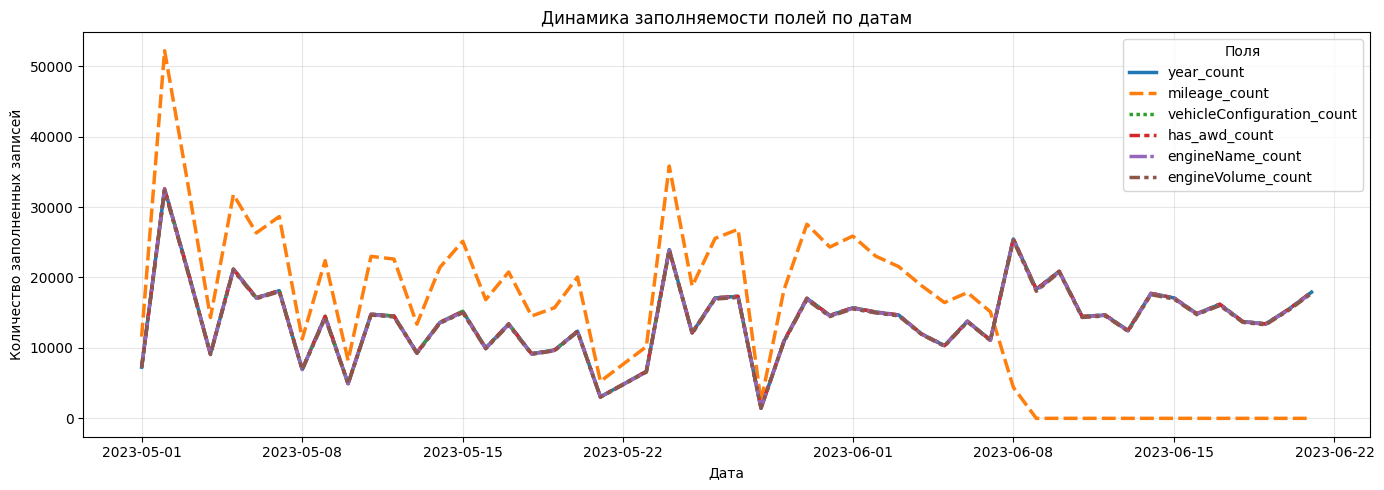

time: 279 ms (started: 2026-05-30 18:22:23 +03:00)


In [10]:
plt.figure(figsize=(14, 5))
sns.lineplot(data=result.set_index("date"), linewidth=2.5)
plt.title("Динамика заполняемости полей по датам")
plt.xlabel("Дата")
plt.ylabel("Количество заполненных записей")
plt.xticks(rotation=0)
plt.legend(title="Поля")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

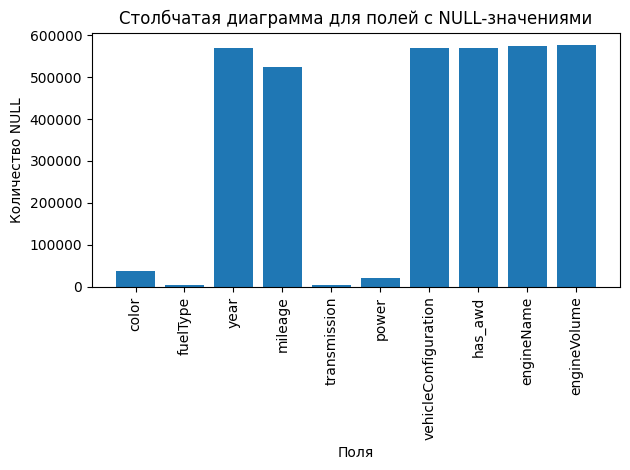

time: 144 ms (started: 2026-05-30 18:22:23 +03:00)


In [11]:
filtered_data = df_rez_null_count[df_rez_null_count["Null Count"] > 0]
plt.bar(filtered_data["field"], filtered_data["Null Count"])

plt.title("Столбчатая диаграмма для полей с NULL-значениями")
plt.xlabel("Поля")
plt.ylabel("Количество NULL")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


## Формирование отчета аналогичного `pandas .describe()`

In [12]:
sql = f"""SELECT name
FROM system.columns
WHERE database = '{db}'
  AND table = '{table}'
  AND (
    type LIKE '%Int%' OR
    type LIKE '%UInt%' OR
    type LIKE '%Float%' OR
    type LIKE '%Decimal%'
  )
ORDER BY name;"""  # noqa: S608
result = client.query_df(sql)
columns_numeric = result["name"].to_list()

agg_funcs = {
    "count": "count",
    "mean": "avg",
    "std": "stddevPop",
    "min": "min",
    "25%": "quantile(0.25)",
    "50%": "quantile(0.50)",
    "75%": "quantile(0.75)",
    "max": "max",
}
totals = {}
for column in columns_numeric:
    totals[f"total_{column}"] = {}
    for key, func in agg_funcs.items():
        sql = f"""SELECT {func}({column}) FROM {db}.{table};"""  # noqa: S608
        result = client.query(sql)
        totals[f"total_{column}"].setdefault(key, 0)
        totals[f"total_{column}"][key] = result.result_rows[0][0]
totals_df = pd.DataFrame(totals)
with pd.option_context(
    "display.float_format",
    "{:.2f}".format,
    "display.expand_frame_repr",
    False,
):
    display(totals_df)


,total_engineVolume,total_mileage,total_power,total_price,total_year
count,717625.00,771799.00,1273353.00,1294757.00,724644.00
mean,1.95,154893.40,141.56,1444357.82,2009.68
std,0.76,100738.27,65.64,1970256.65,9.37
min,0.50,1000.00,1.00,270.00,1936.00
25%,1.50,80000.00,98.00,468750.00,2004.00
50%,1.70,141000.00,125.00,955000.00,2011.00
75%,2.00,212000.00,160.00,2099000.00,2017.00
max,8.40,1000000.00,1000.00,150000000.00,2023.00


time: 410 ms (started: 2026-05-30 18:22:23 +03:00)


## Формирование нескольких выборок для формирования отчета аналогичного `pandas .describe()`
Для очень большого набора данных может быть выгоднее сформировать отчет на выборке данных и по результатам анализа судить о положении дел в выборке в целом. 

В данном примере мы разбиваем исходный набор данных на `sample_count` диапазонов из которых впоследствии выбираем `sample_size` данных.

In [13]:
cars_columns2 = table_columns.copy()
# cars_columns2.remove("link")
# cars_columns2.remove("description")

dfs = []
sample_count = 3
sql = f"""
WITH ranked AS (
    SELECT
        {",".join(cars_columns2)},
        NTILE({sample_count}) OVER (ORDER BY rand()) AS tile
    FROM {db}.{table}
),
ranked_with_row_num AS (
    SELECT
        *,
        ROW_NUMBER() OVER (PARTITION BY tile ORDER BY rand()) AS row_num
    FROM ranked
)
SELECT *
FROM ranked_with_row_num
WHERE row_num <= {sample_size}
"""  # noqa: S608
df = client.query_df(sql)
df_renamed = df.rename(
    columns={"engineDisplacement": "ED", "vehicleConfiguration": "VC"}
)

for group_id in range(1, sample_count + 1):
    dfs.append(df_renamed[df_renamed["tile"] == group_id])  # noqa: PERF401


time: 3.75 s (started: 2026-05-30 18:22:24 +03:00)


In [14]:
dfs[0].sample(5)

,brand,name,bodyType,color,fuelType,year,mileage,transmission,power,price,VC,has_awd,engineName,engineVolume,date,location,parse_date,tile,row_num
38183,Toyota,Harrier,Джип 5 дв.,Белый,Бензин,2017,9000,Вариатор,151,2300000,2.0 Premium Metal and Leather Package,False,3ZR-FAE,2.0,2023-05-01,Якутск,2023-05-06 00:00:00,1,12288
38290,Volkswagen,Touareg,Джип 5 дв.,Коричневый,Бензин,<NA>,122000,АКПП,249,1997000,<NA>,None,<NA>,NaN,2023-05-29,Москва,2023-05-29 23:00:00,1,12395
36870,Toyota,Kluger V,Джип 5 дв.,Белый,Бензин,2000,1000,АКПП,160,780000,2.4 V,False,2AZ-FE,2.4,2023-05-31,Улан-Удэ,2023-05-31 08:00:00,1,10975
31705,Nissan,AD,Универсал,Белый,Бензин,<NA>,<NA>,АКПП,100,185000,<NA>,None,<NA>,NaN,2023-06-21,Омск,2023-06-21 18:00:00,1,5810
26712,Mitsubishi,Outlander,Джип 5 дв.,Черный,Бензин,<NA>,411000,Вариатор,170,965000,<NA>,None,<NA>,NaN,2023-05-05,Москва,2023-05-05 15:00:00,1,817


time: 12.4 ms (started: 2026-05-30 18:22:28 +03:00)


## Получение описательной статистики по выборкам

In [15]:
fields = columns_numeric  # ["price", "power", "year"]
descs = []
descs.append(totals_df)
for i in range(sample_count):
    desc = dfs[i][fields].describe()
    desc.columns = [f"df{i + 1}_{col}" for col in desc.columns]
    descs.append(desc)

combined_desc = pd.concat(descs, axis=1)

with pd.option_context(
    "display.float_format",
    "{:.2f}".format,
    "display.expand_frame_repr",
    False,
):
    display(combined_desc)


,total_engineVolume,total_mileage,total_power,total_price,total_year,df1_engineVolume,df1_mileage,df1_power,df1_price,df1_year,df2_engineVolume,df2_mileage,df2_power,df2_price,df2_year,df3_engineVolume,df3_mileage,df3_power,df3_price,df3_year
count,717625.00,771799.00,1273353.00,1294757.00,724644.00,7247.00,7793.00,12756.00,12948.00,7311.00,7200.00,7774.00,12719.00,12948.00,7271.00,7168.00,7701.00,12733.00,12948.00,7231.00
mean,1.95,154893.40,141.56,1444357.82,2009.68,1.95,155451.69,140.87,1410442.02,2009.46,1.97,155972.99,142.57,1442499.13,2009.73,1.96,156088.43,141.57,1464307.10,2009.60
std,0.76,100738.27,65.64,1970256.65,9.37,0.77,101787.10,64.03,1859575.82,9.43,0.75,102375.79,65.65,1897564.57,9.29,0.76,103233.83,66.94,2212324.01,9.18
min,0.50,1000.00,1.00,270.00,1936.00,0.50,1000.00,33.00,23000.00,1953.00,0.60,1000.00,27.00,6000.00,1953.00,0.60,1000.00,30.00,10000.00,1953.00
25%,1.50,80000.00,98.00,468750.00,2004.00,1.50,80000.00,98.00,400000.00,2003.00,1.50,82000.00,98.00,428500.00,2004.00,1.50,83000.00,98.00,425000.00,2003.00
50%,1.70,141000.00,125.00,955000.00,2011.00,1.70,145000.00,128.00,865000.00,2011.00,1.80,146000.00,129.00,870000.00,2011.00,1.70,143000.00,128.00,870000.00,2011.00
75%,2.00,212000.00,160.00,2099000.00,2017.00,2.00,211000.00,160.00,1720000.00,2017.00,2.10,214000.00,167.00,1750000.00,2017.00,2.00,211000.00,163.00,1750000.00,2017.00
max,8.40,1000000.00,1000.00,150000000.00,2023.00,6.70,1000000.00,702.00,30500000.00,2023.00,6.40,1000000.00,693.00,39000000.00,2023.00,6.70,1000000.00,702.00,99999999.00,2023.00


time: 50 ms (started: 2026-05-30 18:22:28 +03:00)


## Сравнение описательной статистики по выборкам с общими данными на предмет наличия/отсутствия существенных расхождений

In [16]:
new_df = totals_df.copy()
rows = new_df.index.tolist()
rows.remove("min")
rows.remove("max")

fields = columns_numeric  # ["price", "power", "year"]
for field in fields:
    new_df.loc[rows, f"avg_{field}"] = (
        combined_desc.loc[rows].filter(regex=rf"df\d+_{field}").sum(axis=1)
        / sample_count
    )
    new_df[f"{field}_diff"] = new_df[f"total_{field}"] - new_df[f"avg_{field}"]
    new_df[f"{field}_diff_P"] = 100 - round(
        (new_df[f"avg_{field}"] * 100) / new_df[f"total_{field}"], 2
    )

result = new_df.filter(regex="^total_|_diff_P$")

with pd.option_context(
    "display.float_format",
    "{:.2f}".format,
    "display.expand_frame_repr",
    False,
):
    display(result)


,total_engineVolume,total_mileage,total_power,total_price,total_year,engineVolume_diff_P,mileage_diff_P,power_diff_P,price_diff_P,year_diff_P
count,717625.00,771799.00,1273353.00,1294757.00,724644.00,99.00,99.00,99.00,99.00,99.00
mean,1.95,154893.40,141.56,1444357.82,2009.68,-0.48,-0.61,-0.08,0.37,0.00
std,0.76,100738.27,65.64,1970256.65,9.37,-0.44,-1.71,0.15,-0.99,0.70
min,0.50,1000.00,1.00,270.00,1936.00,NaN,<NA>,<NA>,NaN,<NA>
25%,1.50,80000.00,98.00,468750.00,2004.00,0.00,-2.08,0.00,10.86,0.03
50%,1.70,141000.00,125.00,955000.00,2011.00,-1.96,-2.60,-2.67,9.08,0.00
75%,2.00,212000.00,160.00,2099000.00,2017.00,-1.67,0.00,-2.08,17.10,0.00
max,8.40,1000000.00,1000.00,150000000.00,2023.00,NaN,<NA>,<NA>,NaN,<NA>


time: 30 ms (started: 2026-05-30 18:22:28 +03:00)


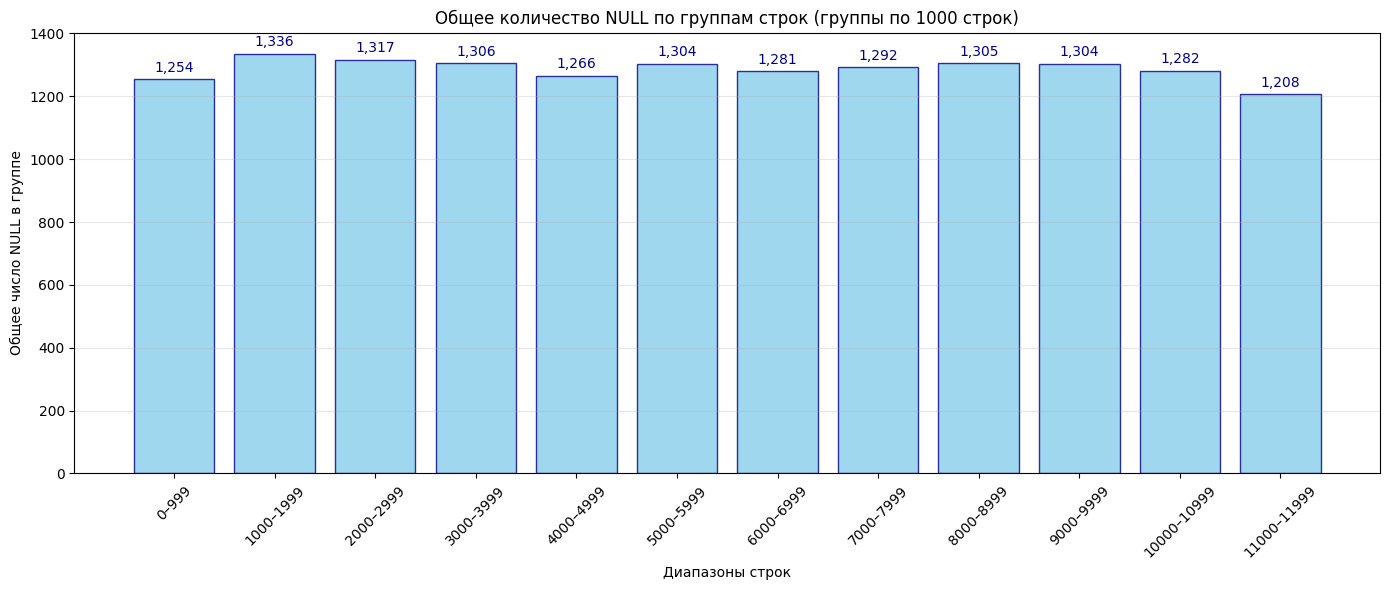

time: 179 ms (started: 2026-05-30 18:22:28 +03:00)


In [17]:
row_null_count = dfs[0][columns_numeric].isna().sum(axis=1)

# Параметры группировки
group_size = 1000  # размер группы строк
n_groups = len(row_null_count) // group_size

# Агрегируем: общее количество NULL для каждой группы
aggregated_counts = []
group_labels = []

for i in range(n_groups):
    start_row = i * group_size
    end_row = start_row + group_size
    group_data = row_null_count.iloc[start_row:end_row]
    aggregated_counts.append(group_data.sum())  # Суммируем все NULL в группе
    group_labels.append(f"{start_row}–{end_row - 1}")

# Строим график
fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(
    group_labels, aggregated_counts, color="skyblue", edgecolor="navy", alpha=0.8
)

# Добавляем значения на столбцы
ax.bar_label(
    bars,
    labels=[f"{int(val):,}" for val in aggregated_counts],
    label_type="edge",
    fontsize=10,
    color="darkblue",
    padding=3,
)

ax.set_title(f"Общее количество NULL по группам строк (группы по {group_size} строк)")
ax.set_xlabel("Диапазоны строк")
ax.set_ylabel("Общее число NULL в группе")
plt.xticks(rotation=45)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


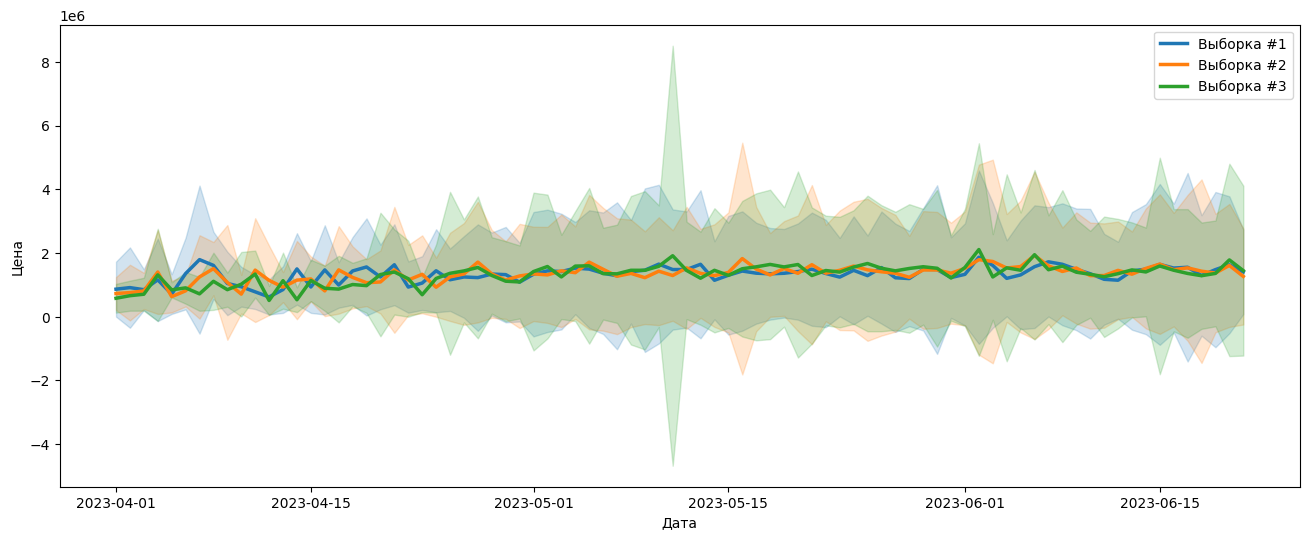

time: 352 ms (started: 2026-05-30 18:22:28 +03:00)


In [18]:
plt.figure(figsize=(16, 6))
for idx, df_number in enumerate(dfs, 1):
    sns.lineplot(
        x="date",
        y="price",
        data=df_number,
        linewidth=2.5,
        errorbar="sd",
        label=f"Выборка #{idx}",
    )
plt.xlabel("Дата")
plt.ylabel("Цена")
plt.show()

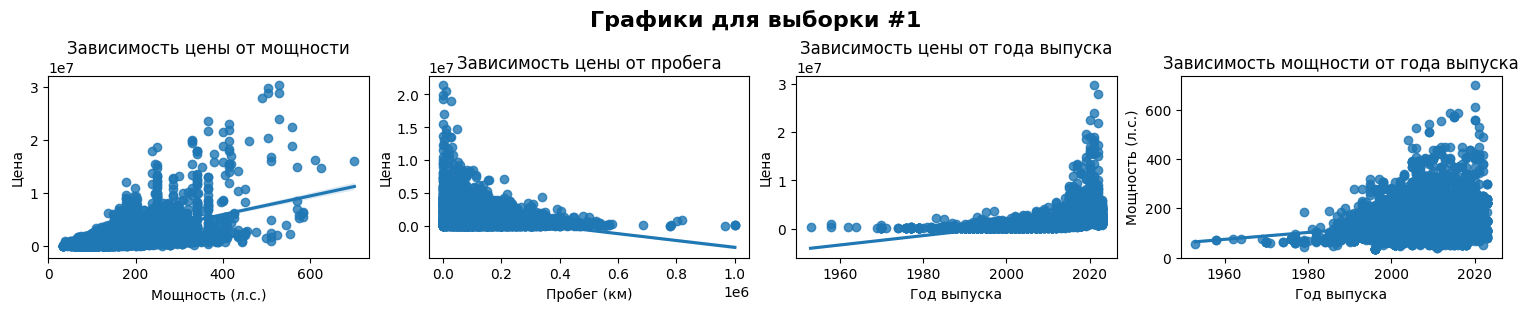

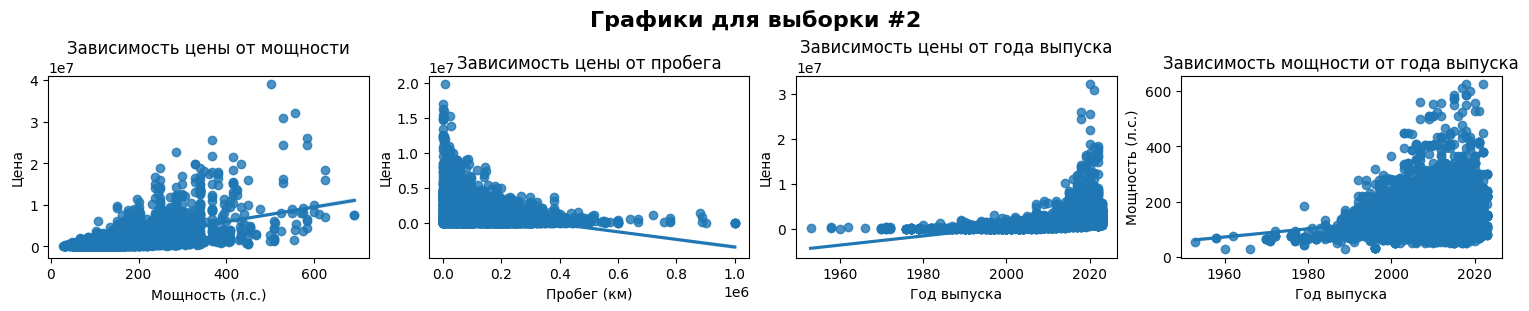

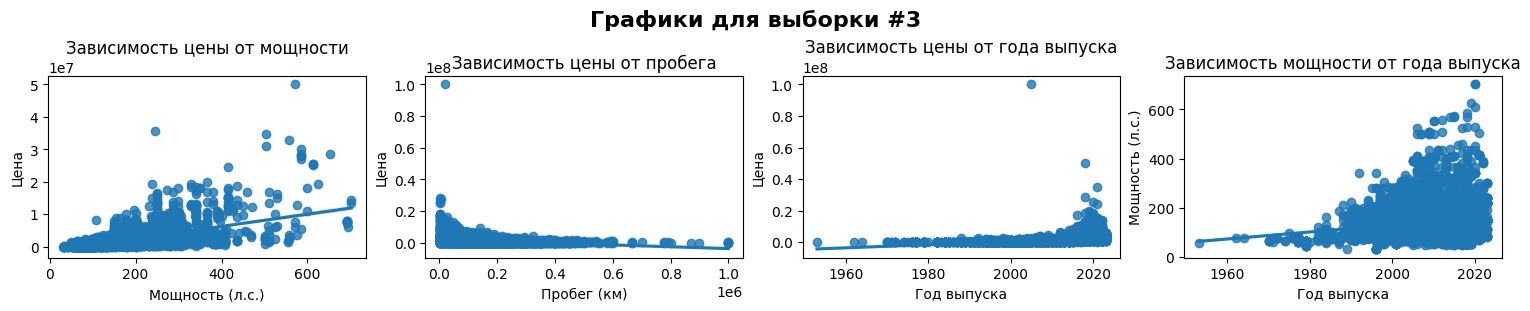

time: 5.4 s (started: 2026-05-30 18:22:28 +03:00)


In [19]:
for idx, df_number in enumerate(dfs):
    fig, axes = plt.subplots(1, 4, figsize=(15, 3), constrained_layout=True)
    fig.suptitle(f"Графики для выборки #{idx + 1}", fontsize=16, fontweight="bold")

    # График 1: power vs price
    sns.regplot(data=dfs[idx], x="power", y="price", ax=axes[0])
    axes[0].set_xlabel("Мощность (л.с.)")
    axes[0].set_ylabel("Цена")
    axes[0].set_title("Зависимость цены от мощности")

    # График 2: mileage vs price
    sns.regplot(data=dfs[idx], x="mileage", y="price", ax=axes[1])
    axes[1].set_xlabel("Пробег (км)")
    axes[1].set_ylabel("Цена")
    axes[1].set_title("Зависимость цены от пробега")

    # График 3: year vs price
    sns.regplot(data=dfs[idx], x="year", y="price", ax=axes[2])
    axes[2].set_xlabel("Год выпуска")
    axes[2].set_ylabel("Цена")
    axes[2].set_title("Зависимость цены от года выпуска")

    # График 4: year vs power
    sns.regplot(data=dfs[idx], x="year", y="power", ax=axes[3])
    axes[3].set_xlabel("Год выпуска")
    axes[3].set_ylabel("Мощность (л.с.)")
    axes[3].set_title("Зависимость мощности от года выпуска")

plt.show()


In [20]:
end_time = time.perf_counter()
total_time = end_time - start_time
print(f"Общее время выполнения: {total_time:.4f} секунд")

Общее время выполнения: 11.7921 секунд
time: 556 μs (started: 2026-05-30 18:22:34 +03:00)
